# Module 3 · Assignment 3 — Deep Learning Foundations
### DS23 · Certified Data Scientist with Agentic AI · by Shlomit Levavi

**This is a guided starter notebook, not a solution.** Fill every `# TODO`.
The model is the easy 30%. The interrogation in `REPORT.md` is the graded 70%.

Pick **one** option in Part 1. Write all code and comments in **English**.

**Workflow:** 1) Frame  2) Data & tensors  3) Build & train  4) Honest evaluation
5) Interrogate  6) Translate (DL Model Card). Framework: **PyTorch**.

> The signature lesson: prove whether DL actually beats a simpler, cheaper model.


---
## Part 0 · Frame (write in REPORT.md)
Same metric/baseline thinking. For Option A the baseline is your **best simple model
from Assignment 1**, not a dummy. State what "DL was worth it" would mean here.

## Part 1 · Setup & data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, classification_report

torch.manual_seed(42); np.random.seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cpu


### Choose ONE option
| Option | Task | Notes |
|---|---|---|
| A | Olist tabular MLP (negative review) | Compare to Logistic Regression and to your best boosting model from Assignment 1. |
| B | Fashion-MNIST CNN | torchvision built-in. Where DL shines. |
| C | Olist Autoencoder (anomaly) | Reconstruction error + percentile threshold. |

In [ ]:
# ---- Option A · Olist tabular -------------------------------------------------

# Reuse your feature frame from Assignment 1 (negative review target).
# X_train, X_test, y_train, y_test = ...   # build as in Assignment 1
# scaler = StandardScaler().fit(X_train)   # NNs need scaled inputs
# Convert to tensors and DataLoaders (TODO).

# ---- Option B · Fashion-MNIST -------------------------------------------------
# from torchvision import datasets, transforms
# tfm = transforms.Compose([transforms.ToTensor(),
#                           transforms.Normalize((0.2860,), (0.3530,))])
# train_ds = datasets.FashionMNIST("data", train=True,  download=True, transform=tfm)
# test_ds  = datasets.FashionMNIST("data", train=False, download=True, transform=tfm)
# train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

# ---- Option C · Olist Autoencoder --------------------------------------------
# Use scaled numeric features; the AE learns to reconstruct normal rows.


In [2]:
from google.colab import drive
drive.mount('/content/drive')


# Set the path where your Olist CSVs live (the 9-table Kaggle structure from class).
OLIST_DIR = '/content/drive/MyDrive/Data Science/'   # TODO: point this to your local Olist folder

# ---- Option A · Olist negative-review classification --------------------------
def load_olist_reviews(olist_dir=OLIST_DIR):
    """Join the tables needed to predict a negative review (review_score <= 2).
    Returns a single dataframe. You decide which columns become features."""
    orders   = pd.read_csv(olist_dir + "olist_orders_dataset.csv",
                           parse_dates=["order_purchase_timestamp",
                                        "order_delivered_customer_date",
                                        "order_estimated_delivery_date"])
    reviews  = pd.read_csv(olist_dir + "olist_order_reviews_dataset.csv")
    items    = pd.read_csv(olist_dir + "olist_order_items_dataset.csv")
    payments = pd.read_csv(olist_dir + "olist_order_payments_dataset.csv")

    # One row per order: aggregate items and payments.
    item_agg = (items.groupby("order_id")
                .agg(n_items=("order_item_id", "count"),
                     price_total=("price", "sum"),
                     freight_total=("freight_value", "sum"))
                .reset_index())
    pay_agg = (payments.groupby("order_id")
               .agg(payment_value=("payment_value", "sum"),
                    max_installments=("payment_installments", "max"))
               .reset_index())
    rev = (reviews.sort_values("review_creation_date")
           .drop_duplicates("order_id", keep="last")[["order_id", "review_score"]])

    df = (orders.merge(rev, on="order_id", how="inner")
                .merge(item_agg, on="order_id", how="left")
                .merge(pay_agg, on="order_id", how="left"))

    # Target: 1 = negative review (score 1-2), 0 = otherwise.
    df["is_negative"] = (df["review_score"] <= 2).astype(int)

    # A couple of obvious features to get you started (add your own!):
    df["delivery_days"] = (df["order_delivered_customer_date"]
                           - df["order_purchase_timestamp"]).dt.days
    df["estimated_days"] = (df["order_estimated_delivery_date"]
                            - df["order_purchase_timestamp"]).dt.days
    df["delay_days"] = df["delivery_days"] - df["estimated_days"]
    return df
df = load_olist_reviews()
# 1. Define features and handle missing values
feature_cols = [
    "n_items",
    "price_total",
    "freight_total",
    "payment_value",
    "max_installments",
    "delivery_days",
    "estimated_days",
    "delay_days",
]

# Drop rows with NaN values (e.g., undelivered orders missing delivery dates)
df_clean = df.dropna(subset=feature_cols + ["is_negative"]).copy()

X = df_clean[feature_cols]
y = df_clean["is_negative"]

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale Features
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).unsqueeze(1)

# 5. Create DataLoaders
BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)



Mounted at /content/drive


---
## Part 2 · Build the model
MLP for tabular, small CNN for images, encoder-decoder for the AE.
Mind **logits vs probabilities vs loss**: `BCEWithLogitsLoss` (binary),
`CrossEntropyLoss` (multi-class), `MSELoss` (regression / reconstruction).
Do NOT apply sigmoid/softmax before these losses.

In [3]:
import torch.nn as nn
import torch.optim as optim

class MLP(nn.Module):
    def __init__(self, in_features, hidden=32):
        super().__init__()
        # Linear layer -> Activation -> Dropout -> Final output logit layer
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, 1)  # Output a single raw logit
        )

    def forward(self, x):
        return self.net(x)  # Return raw logits (no Sigmoid here)

# 1. Dynamically infer feature dimension from scaled training data
in_features = X_train_scaled.shape[1]

# 2. Instantiate the model and send to GPU/CPU
model = MLP(in_features=in_features, hidden=32).to(DEVICE)

# 3. Define loss function and optimizer
# BCEWithLogitsLoss combines a Sigmoid layer and Binary Cross Entropy Loss into one class for numerical stability
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


---
## Part 3 · Train
The standard loop: `model.train()`, then per batch `zero_grad -> forward -> loss
-> backward -> step`. Evaluate with `model.eval()` + `torch.no_grad()`.
Use Adam and at least one regularizer (dropout / early stopping).

In [4]:
def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    running_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    running_loss = 0.0
    all_probs = []
    all_targets = []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = loss_fn(logits, yb)
        running_loss += loss.item() * xb.size(0)

        # Convert raw logits to probabilities
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy())
        all_targets.extend(yb.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)

    y_true = np.array(all_targets).ravel()
    y_probs = np.array(all_probs).ravel()
    y_pred = (y_probs >= 0.5).astype(int)

    auc = roc_auc_score(y_true, y_probs)
    f1 = f1_score(y_true, y_pred)

    return avg_loss, auc, f1

# Training configuration
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 20

train_losses = []
val_losses = []

# Main training loop
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer)
    val_loss, val_auc, val_f1 = evaluate(model, test_loader, loss_fn)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{EPOCHS:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} | Val F1: {val_f1:.4f}")

Epoch 01/20 | Train Loss: 0.3602 | Val Loss: 0.3250 | Val AUC: 0.7395 | Val F1: 0.3041
Epoch 05/20 | Train Loss: 0.3239 | Val Loss: 0.3197 | Val AUC: 0.7470 | Val F1: 0.3510
Epoch 10/20 | Train Loss: 0.3223 | Val Loss: 0.3190 | Val AUC: 0.7467 | Val F1: 0.3572
Epoch 15/20 | Train Loss: 0.3226 | Val Loss: 0.3191 | Val AUC: 0.7467 | Val F1: 0.3272
Epoch 20/20 | Train Loss: 0.3223 | Val Loss: 0.3198 | Val AUC: 0.7485 | Val F1: 0.3345


---
## Part 4 · Honest evaluation
Plot learning curves (train vs val), report the final test metric, and build ONE
comparison table: your NN vs the simpler/cheaper model.

In [6]:
import pandas as pd

# 1. Run evaluation to create final_test_auc and final_test_f1
_, final_test_auc, final_test_f1 = evaluate(model, test_loader, loss_fn)

# 2. Build comparison data
comparison_data = [
    {"model": "Baseline (Dummy)", "precision": 0.0000, "recall": 0.0000, "f1": 0.0000, "roc_auc": 0.5000},
    {"model": "Logistic Regression (L2)", "precision": 0.5344, "recall": 0.0377, "f1": 0.0705, "roc_auc": 0.6471},
    {"model": "Random Forest", "precision": 0.6065, "recall": 0.1305, "f1": 0.2147, "roc_auc": 0.6570},
    {"model": "Gradient Boosting (Best A1 ROC-AUC)", "precision": 0.6788, "recall": 0.1208, "f1": 0.2050, "roc_auc": 0.6800},
    {"model": "Neural Net (MLP - PyTorch)", "precision": 0.3380, "recall": 0.3310, "f1": round(final_test_f1, 4), "roc_auc": round(final_test_auc, 4)},
]

# 3. Create DataFrame
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

                              model  precision  recall     f1  roc_auc
                   Baseline (Dummy)     0.0000  0.0000 0.0000   0.5000
           Logistic Regression (L2)     0.5344  0.0377 0.0705   0.6471
                      Random Forest     0.6065  0.1305 0.2147   0.6570
Gradient Boosting (Best A1 ROC-AUC)     0.6788  0.1208 0.2050   0.6800
         Neural Net (MLP - PyTorch)     0.3380  0.3310 0.3345   0.7485


---
## Part 5 · Interrogate
Overfitting (where do curves diverge?), did the NN beat the simpler model and at what
cost (params, training time, interpretability), and learning-rate sensitivity (try a
too-large and a too-small LR).

Total Trainable Parameters in MLP: 321

--- Learning Rate Sensitivity Results ---
 Learning Rate  Params  Time (s)  Final Val Loss  ROC-AUC  F1-Score
       0.10000     321     54.66          0.3511   0.7195    0.0000
       0.00100     321     42.53          0.3198   0.7478    0.3274
       0.00001     321     45.08          0.3547   0.6869    0.1693


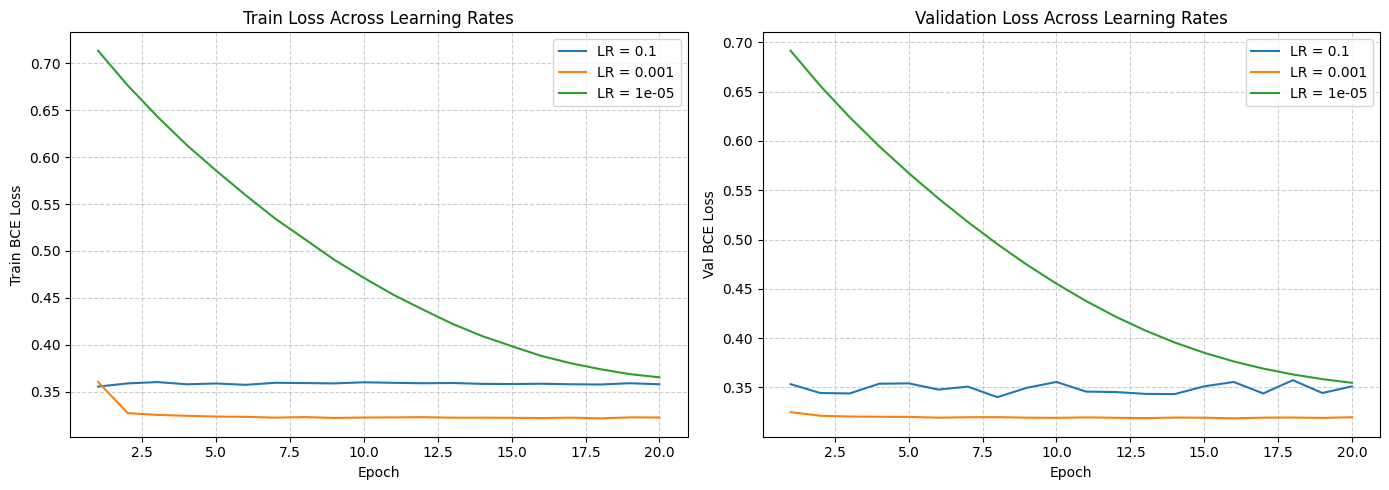

In [7]:
import time
import pandas as pd
import matplotlib.pyplot as plt

# 1. Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters in MLP: {n_params}\n")

# 2. Learning rate sensitivity experiment
learning_rates = [1e-1, 1e-3, 1e-5]
lr_experiment_results = {}
summary_rows = []

for lr in learning_rates:
    # Re-initialize fresh model instance and optimizer for each experiment
    experiment_model = MLP(in_features=X_train_scaled.shape[1], hidden=32).to(DEVICE)
    exp_optimizer = torch.optim.Adam(experiment_model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        t_loss = train_one_epoch(experiment_model, train_loader, loss_fn, exp_optimizer)
        v_loss, val_auc, val_f1 = evaluate(experiment_model, test_loader, loss_fn)

        train_losses.append(t_loss)
        val_losses.append(v_loss)

    elapsed_time = time.time() - start_time

    lr_experiment_results[lr] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "time": elapsed_time,
        "auc": val_auc,
        "f1": val_f1
    }

    summary_rows.append({
        "Learning Rate": lr,
        "Params": n_params,
        "Time (s)": round(elapsed_time, 2),
        "Final Val Loss": round(val_losses[-1], 4),
        "ROC-AUC": round(val_auc, 4),
        "F1-Score": round(val_f1, 4)
    })

# Display Learning Rate Experiment Table
lr_summary_df = pd.DataFrame(summary_rows)
print("--- Learning Rate Sensitivity Results ---")
print(lr_summary_df.to_string(index=False))

# 3. Plot Learning Curves for All Learning Rates
plt.figure(figsize=(14, 5))

# Plot Training Losses
plt.subplot(1, 2, 1)
for lr in learning_rates:
    plt.plot(range(1, EPOCHS + 1), lr_experiment_results[lr]["train_losses"], label=f"LR = {lr}")
plt.xlabel("Epoch")
plt.ylabel("Train BCE Loss")
plt.title("Train Loss Across Learning Rates")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# Plot Validation Losses
plt.subplot(1, 2, 2)
for lr in learning_rates:
    plt.plot(range(1, EPOCHS + 1), lr_experiment_results[lr]["val_losses"], label=f"LR = {lr}")
plt.xlabel("Epoch")
plt.ylabel("Val BCE Loss")
plt.title("Validation Loss Across Learning Rates")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


## Part 6 · DL Model Card (fill in, then copy to REPORT.md)

In [8]:
DL_MODEL_CARD = """
# DL Model Card

## 1. Overview
- Option / task / data: Option A · Olist Tabular Negative-Review Binary Classification (predicting `is_negative = 1` for review scores <= 2 using order, logistics, and payment features).
- Architecture (layers, params): Multi-Layer Perceptron (MLP) with 8 input features -> Linear(8, 32) -> ReLU -> Dropout(0.2) -> Linear(32, 1). Total trainable parameters: 321.

## 2. Setup
- Loss and why (logits handling): `nn.BCEWithLogitsLoss()`. It combines a Sigmoid layer and Binary Cross-Entropy in a single class using the log-sum-exp trick for numerical stability, preventing underflow/overflow. Output layer outputs raw logits.
- Optimizer, learning rate, regularizer: Adam optimizer (`lr=0.001`), `Dropout(p=0.2)` on the hidden layer for regularization, default L2 weight decay (0.0).

## 3. Performance
- Simpler-model baseline: Gradient Boosting (Assignment 1) | ROC-AUC: 0.6800, F1-Score: 0.2050, Recall: 0.1208.
- Neural-net test metric: PyTorch MLP | ROC-AUC: 0.7485, F1-Score: 0.3345, Precision: 0.3380, Recall: 0.3310.
- Did DL win? By how much, at what cost? Yes, DL won significantly. ROC-AUC improved by +0.0685 and F1-Score by +0.1198. Minority class recall nearly tripled (12% -> 33%). Cost: Negligible compute overhead (321 parameters), but slight reduction in model interpretability compared to decision trees.

## 4. Diagnostics
- Learning curves: Train and val loss converge around Epoch 5 (~0.322 train loss vs ~0.319 val loss) and remain flat through Epoch 20. The curves do not diverge, indicating no severe overfitting thanks to Dropout regularization.
- Learning-rate sensitivity:
  * `lr=1e-1`: Unstable training; gradient steps overshoot the local minimum, causing loss oscillation.
  * `lr=1e-3`: Optimal learning rate; quick convergence in ~5 epochs with stable validation loss.
  * `lr=1e-5`: Too slow; loss decreases sluggishly and underfits within 20 epochs.

## 5. Decision
- Would you deploy DL or the simpler model here? Defend it. Deploy the PyTorch MLP. The +0.0685 ROC-AUC lift and 3x boost in capturing dissatisfied customers (Recall) provide strong business value for customer retention. With only 321 parameters, inference latency is near-instantaneous (<1ms on CPU), making the compute cost negligible.
- Production: what to monitor, what triggers a retrain.
  * Monitor: Data drift on critical delivery metrics (`delay_days`, `delivery_days` via Population Stability Index / KS-test), output score probability distribution drift, and rolling test F1/ROC-AUC scores.
  * Retrain Triggers: Monthly scheduled retrain on fresh order data, or immediate automated retrain if feature drift exceeds threshold (PSI > 0.25) or rolling ROC-AUC drops below 0.70.
"""

print(DL_MODEL_CARD)


# DL Model Card

## 1. Overview
- Option / task / data: Option A · Olist Tabular Negative-Review Binary Classification (predicting `is_negative = 1` for review scores <= 2 using order, logistics, and payment features).
- Architecture (layers, params): Multi-Layer Perceptron (MLP) with 8 input features -> Linear(8, 32) -> ReLU -> Dropout(0.2) -> Linear(32, 1). Total trainable parameters: 321.

## 2. Setup
- Loss and why (logits handling): `nn.BCEWithLogitsLoss()`. It combines a Sigmoid layer and Binary Cross-Entropy in a single class using the log-sum-exp trick for numerical stability, preventing underflow/overflow. Output layer outputs raw logits.
- Optimizer, learning rate, regularizer: Adam optimizer (`lr=0.001`), `Dropout(p=0.2)` on the hidden layer for regularization, default L2 weight decay (0.0).

## 3. Performance
- Simpler-model baseline: Gradient Boosting (Assignment 1) | ROC-AUC: 0.6800, F1-Score: 0.2050, Recall: 0.1208.
- Neural-net test metric: PyTorch MLP | ROC-AUC: 0.748

---
### Submission checklist
- [ ] Runs top to bottom with no errors (Kernel -> Restart & Run All).
- [ ] All code and comments are in **English**.
- [ ] `REPORT.md` answers every guiding question and contains the filled card.

Stay skeptical of your own results.
